#NAME : UNIBHA NEUPANE GROUP:L5CG11 STUDENT ID:2509467

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Human_Development_Index_Dataset.csv", encoding='latin1')

df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


#Problem 1A: Single Year HDI Exploration (2022)

#Task 1: Extract Latest Year (2022

In [8]:
df['year'].unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [12]:
hdi_2022_df = df[df['year'] == 2022].copy()

#Task 2: Data Exploration

In [14]:
hdi_2022_df.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [16]:
hdi_2022_df.shape

(206, 30)

In [17]:
hdi_2022_df.dtypes

,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


#Task 3: Missing Values & Cleaning

In [19]:
hdi_2022_df.isna().sum()


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,2
life_expectancy,0
pop_millions,0
hdi_f,13
hdi_m,13
life_expec_f,0


In [21]:
numeric_cols = ['hdi', 'life_expectancy', 'gross_inc_percap', 'gender_development']

for col in numeric_cols:
    hdi_2022_df[col] = pd.to_numeric(hdi_2022_df[col], errors='coerce')


In [24]:
hdi_2022_df = hdi_2022_df.drop_duplicates()


In [26]:
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi'])


Non-numeric values were converted to NaN, duplicate rows were removed, and rows with missing HDI values were dropped since HDI is required for analysis.


#Task 4: Basic Statistics

In [28]:
hdi_2022_df['hdi'].mean()
hdi_2022_df['hdi'].median()
hdi_2022_df['hdi'].std()


0.15302880386427825

In [30]:
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax()][['country','hdi']]


,5609
country,Switzerland
hdi,0.967


In [32]:
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin()][['country','hdi']]


,5345
country,Somalia
hdi,0.38


#Task 5: Filtering & Sorting

In [34]:
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]


In [36]:
high_hdi_sorted = high_hdi.sort_values(by='gross_inc_percap', ascending=False)
high_hdi_sorted.head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
3332,3333,LIE,Liechtenstein,2022,0.942,84.656,0.039327,0.924163,0.974295,86.129,...,0.949,NaN,NaN,NaN,28.000000,72.000000,52.79,67.26,3.736776,NaN
4718,4719,QAT,Qatar,2022,0.875,81.559,2.695122,0.892561,0.869100,83.101,...,1.027,0.212,81.832741,71.417976,4.444444,95.555556,61.73,95.33,39.884274,63.5912
5213,5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
2705,2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
3398,3399,LUX,Luxembourg,2022,0.927,82.591,0.647599,0.920482,0.927311,84.770,...,0.993,0.043,96.579350,89.328283,33.333333,66.666667,57.99,65.09,13.185395,49.1903
6104,6105,ARE,United Arab Emirates,2022,0.937,79.196,9.441128,0.922940,0.936027,81.412,...,0.986,0.035,82.029137,86.145172,50.000000,50.000000,55.32,89.45,25.333276,28.1632
5609,5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4322,4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
6170,6171,USA,United States,2022,0.927,78.203,338.289857,0.927693,0.923405,81.015,...,1.005,0.180,95.424278,95.067093,28.060264,71.939736,56.79,67.97,14.932487,29.3498
2474,2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,...,0.972,NaN,77.866913,84.067802,NaN,NaN,52.91,64.71,4.373242,NaN


#Task 6: HDI Category Column

In [101]:
def hdi_category(hdi):
    if hdi < 0.550:
        return "Low"
    elif hdi < 0.700:
        return "Medium"
    elif hdi < 0.800:
        return "High"
    else:
        return "Very High"

hdi_2022_df.to_csv("HDI category added.csv", index=False)



In [78]:
hdi_2022_df['HDI Category'].value_counts()


,count
HDI Category,
Very High,71
High,54
Medium,44
Low,35


In [79]:
hdi_2022_df.to_csv("HDI category added.csv", index=False)



HDI categories were assigned using official UNDP threshold values for the year 2022.


#PROBLEM 1B – HDI VISUALIZATION & TREND (2020–2022)

#Task 1: Filter Years

In [102]:
hdi_1b = df[df['year'].isin([2020, 2021, 2022])].copy()
hdi_1b.to_csv("HDI problem1B.csv", index=False)


#Task 2: Cleaning

In [44]:
hdi_1b = hdi_1b.dropna(subset=['hdi','country','year'])
hdi_1b = hdi_1b.drop_duplicates()


In [45]:
hdi_1b['hdi'] = pd.to_numeric(hdi_1b['hdi'], errors='coerce')
hdi_1b['gross_inc_percap'] = pd.to_numeric(hdi_1b['gross_inc_percap'], errors='coerce')




For the 2020–2022 dataset, rows with missing values in essential columns such as country, year, and HDI were removed to ensure consistency in trend and regional analysis. Duplicate records were dropped to avoid double-counting during aggregation.

Numeric columns, including HDI and Gross Nati


#Task 3A: Line Chart – 5 Countries

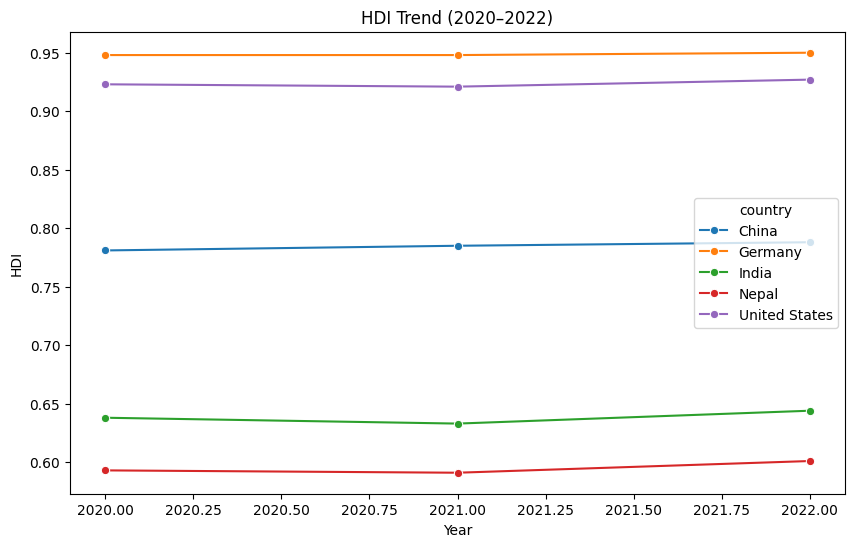

In [47]:
countries = ['Nepal','India','China','United States','Germany']
subset = hdi_1b[hdi_1b['country'].isin(countries)]

plt.figure(figsize=(10,6))
sns.lineplot(data=subset, x='year', y='hdi', hue='country', marker='o')
plt.title("HDI Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.show()


#Task 3B: Visualizations

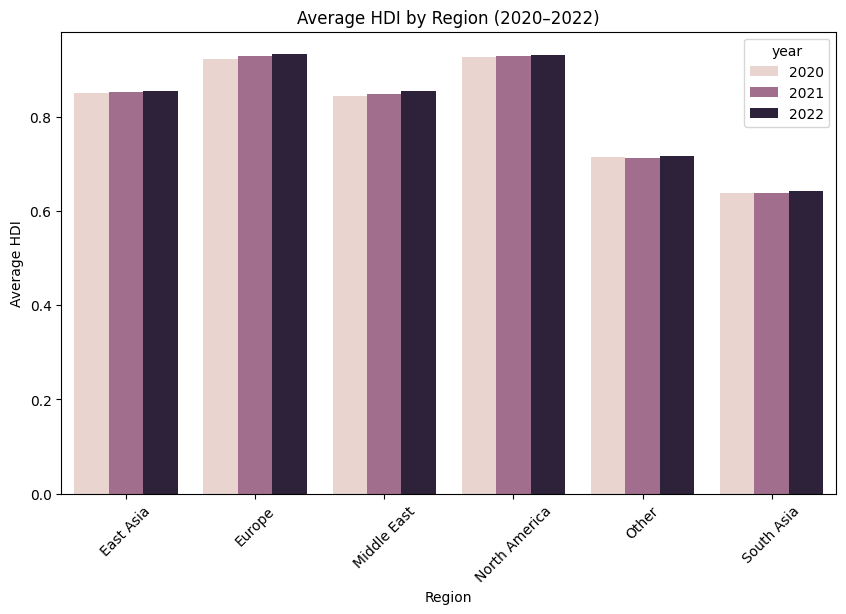

In [81]:
region_avg = hdi_1b.groupby(['region', 'year'])['hdi'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=region_avg, x='region', y='hdi', hue='year')
plt.title("Average HDI by Region (2020–2022)")
plt.xlabel("Region")
plt.ylabel("Average HDI")
plt.xticks(rotation=45)
plt.show()


This bar chart compares average HDI across regions for 2020, 2021, and 2022.


In [75]:
# Creating Region column (derived from Country as instructed)

region_map = {
    "Nepal": "South Asia",
    "India": "South Asia",
    "Pakistan": "South Asia",
    "Bangladesh": "South Asia",
    "Sri Lanka": "South Asia",
    "Bhutan": "South Asia",
    "Maldives": "South Asia",
    "Afghanistan": "South Asia",

    "China": "East Asia",
    "Japan": "East Asia",
    "South Korea": "East Asia",

    "United States": "North America",
    "Canada": "North America",

    "Germany": "Europe",
    "France": "Europe",
    "United Kingdom": "Europe",

    "Qatar": "Middle East",
    "Saudi Arabia": "Middle East",
    "United Arab Emirates": "Middle East",
    "Iran": "Middle East",
    "Iraq": "Middle East",
    "Israel": "Middle East"
}

hdi_1b['region'] = hdi_1b['country'].map(region_map)
hdi_1b['region'] = hdi_1b['region'].fillna("Other")



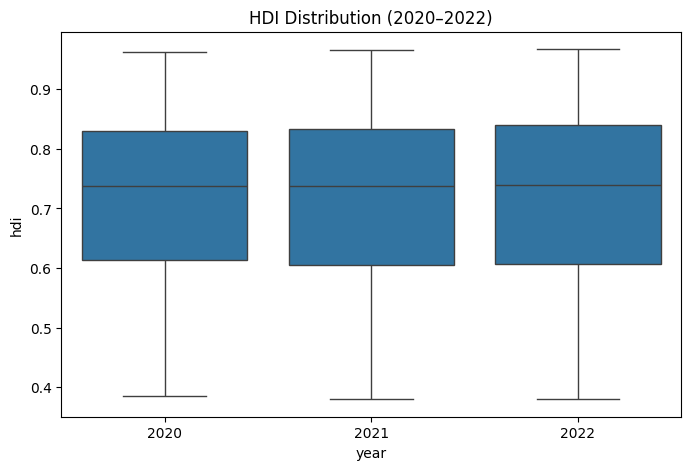

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(data=hdi_1b, x='year', y='hdi')
plt.title("HDI Distribution (2020–2022)")
plt.show()


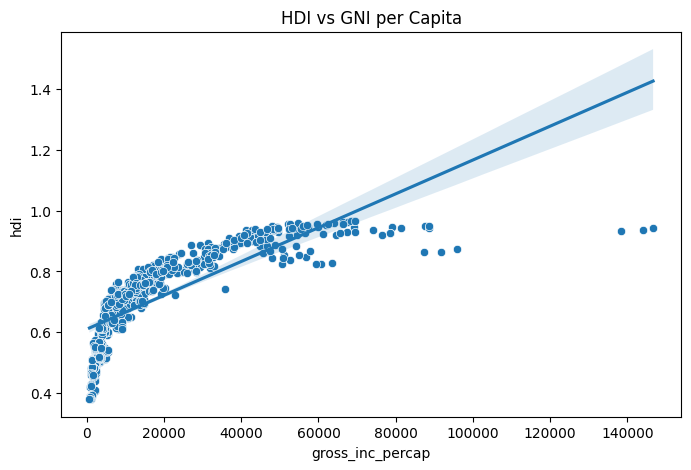

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=hdi_1b, x='gross_inc_percap', y='hdi')
sns.regplot(data=hdi_1b, x='gross_inc_percap', y='hdi', scatter=False)
plt.title("HDI vs GNI per Capita")
plt.show()


#PROBLEM 2 – ADVANCED HDI (SOUTH ASIA)

#Task 1: South Asia Subset

In [103]:
south_asia = ["Afghanistan","Bangladesh","Bhutan","India","Maldives","Nepal","Pakistan","Sri Lanka"]

sa_df = df[df['country'].isin(south_asia)].copy()
sa_df.to_csv("HDI SouthAsia.csv", index=False)


#Task 2: Composite Score

In [58]:
sa_df['Composite_Score'] = (
    0.30 * sa_df['life_expectancy'] +
    0.30 * sa_df['gross_inc_percap']
)


In [60]:
ranked = sa_df.sort_values(by='Composite_Score', ascending=False)


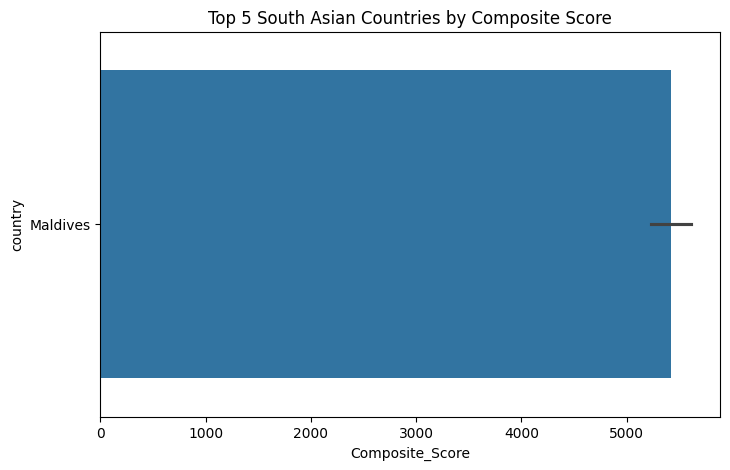

In [61]:
top5 = ranked.head(5)

plt.figure(figsize=(8,5))
sns.barplot(data=top5, x='Composite_Score', y='country')
plt.title("Top 5 South Asian Countries by Composite Score")
plt.show()




A Composite Development Score was calculated for South Asian countries using life expectancy and GNI per capita, each weighted at 30 percent. This simplified composite metric provides an alternative perspective on development and allows comparison with HDI rankings to identify differences arising from the exclusion of education-related indicators.


#Task 3: Outlier Detection (IQR)

In [62]:
Q1 = sa_df['gross_inc_percap'].quantile(0.25)
Q3 = sa_df['gross_inc_percap'].quantile(0.75)
IQR = Q3 - Q1

outliers = sa_df[(sa_df['gross_inc_percap'] < Q1 - 1.5*IQR) |
                 (sa_df['gross_inc_percap'] > Q3 + 1.5*IQR)]




Outliers in Gross National Income (GNI) per capita were identified using the 1.5×IQR (Interquartile Range) method. Values falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were classified as outliers. This method was chosen because it is robust to extreme values and is commonly used to detect unusually high or low economic outcomes across countries.


#Task 4: Correlation

In [63]:
sa_df[['hdi','life_expectancy','gender_development']].corr()


,hdi,life_expectancy,gender_development
hdi,1.000000,0.958761,0.865621
life_expectancy,0.958761,1.000000,0.829553
gender_development,0.865621,0.829553,1.000000


#Task 5: GNI–HDI Gap

In [65]:
sa_df['GNI_HDI_Gap'] = sa_df['gross_inc_percap'] - sa_df['hdi']


In [66]:
sa_df.sort_values(by='GNI_HDI_Gap', ascending=False).head(3)
sa_df.sort_values(by='GNI_HDI_Gap').head(3)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,Composite_Score,GNI_HDI_Gap
11,12,AFG,Afghanistan,2001,0.344,55.798,19.688633,NaN,NaN,57.344,...,2.334909,10.470540,NaN,NaN,NaN,NaN,0.054300,2.1080,311.079466,980.789554
10,11,AFG,Afghanistan,2000,0.340,55.298,19.542983,NaN,NaN,56.858,...,2.162488,9.859265,NaN,NaN,NaN,NaN,0.053579,2.0707,330.792206,1047.002686
9,10,AFG,Afghanistan,1999,0.337,54.846,19.262847,NaN,NaN,56.300,...,2.065200,9.706157,NaN,NaN,NaN,NaN,0.056669,2.0832,353.150571,1121.985570


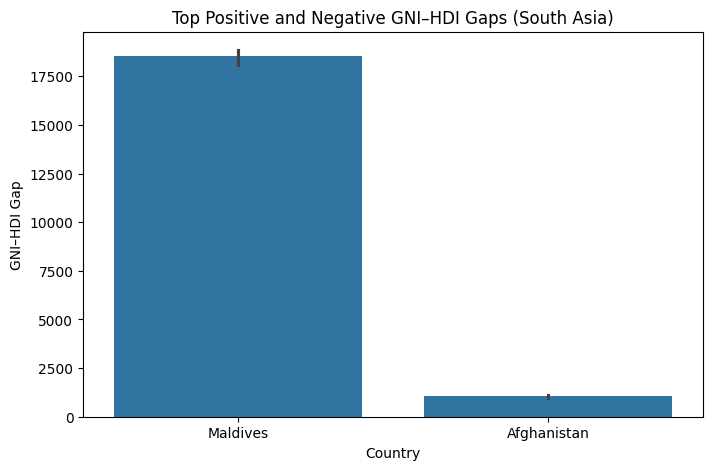

In [82]:
top_positive = sa_df.sort_values('GNI_HDI_Gap', ascending=False).head(3)
top_negative = sa_df.sort_values('GNI_HDI_Gap').head(3)

gap_plot_df = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8,5))
sns.barplot(data=gap_plot_df, x='country', y='GNI_HDI_Gap')
plt.title("Top Positive and Negative GNI–HDI Gaps (South Asia)")
plt.xlabel("Country")
plt.ylabel("GNI–HDI Gap")
plt.show()


The GNI–HDI gap shows that higher income does not always result in higher human development in South Asian countries.


#Task 6: Correlation Analysis (add)

In [88]:
sa_df[['hdi','life_expectancy','gender_development','gross_inc_percap']].corr()


,hdi,life_expectancy,gender_development,gross_inc_percap
hdi,1.000000,0.958761,0.865621,0.801198
life_expectancy,0.958761,1.000000,0.829553,0.800936
gender_development,0.865621,0.829553,1.000000,0.659883
gross_inc_percap,0.801198,0.800936,0.659883,1.000000


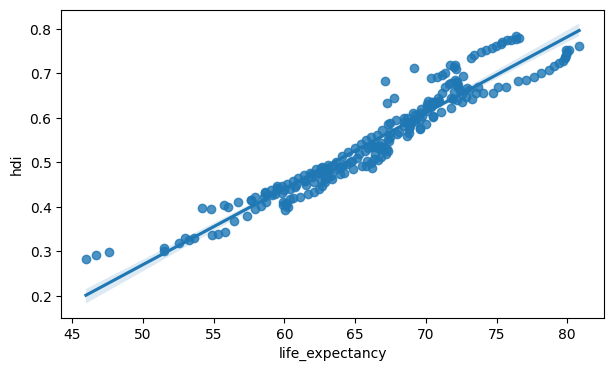

In [89]:
plt.figure(figsize=(7,4))
sns.regplot(data=sa_df, x='life_expectancy', y='hdi')
plt.show()


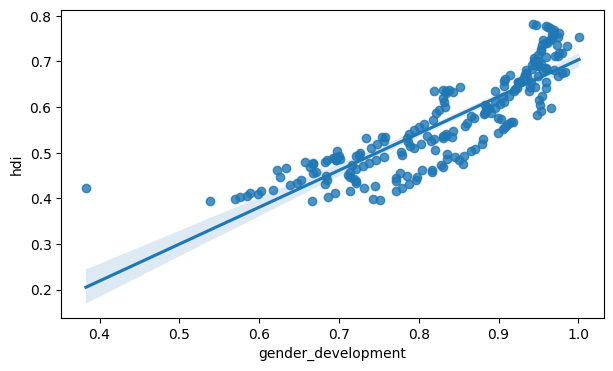

In [90]:
plt.figure(figsize=(7,4))
sns.regplot(data=sa_df, x='gender_development', y='hdi')
plt.show()


#PROBLEM 3 – SOUTH ASIA vs MIDDLE EAST

#Task 1: Subsets

In [105]:
middle_east = ["Bahrain","Iran","Iraq","Israel","Jordan","Kuwait","Lebanon",
               "Oman","Palestine","Qatar","Saudi Arabia","Syria",
               "United Arab Emirates","Yemen"]

sa_3 = hdi_1b[hdi_1b['country'].isin(south_asia)]
me_3 = hdi_1b[hdi_1b['country'].isin(middle_east)]

sa_3.to_csv("HDI SouthAsia 2020 2022.csv", index=False)
me_3.to_csv("HDI MiddleEast 2020 2022.csv", index=False)



#Task 2: Descriptive Statistics

In [68]:
sa_3['hdi'].mean(), sa_3['hdi'].std()
me_3['hdi'].mean(), me_3['hdi'].std()


(np.float64(0.7889090909090909), 0.14129476362297624)

The Middle East shows a higher average HDI compared to South Asia during 2020–2022.


#Task 3: Top & Bottom Countries

In [69]:
sa_3.groupby('country')['hdi'].mean().sort_values(ascending=False).head(3)
sa_3.groupby('country')['hdi'].mean().sort_values().head(3)


,hdi
country,
Afghanistan,0.474333
Pakistan,0.537667
Nepal,0.595000


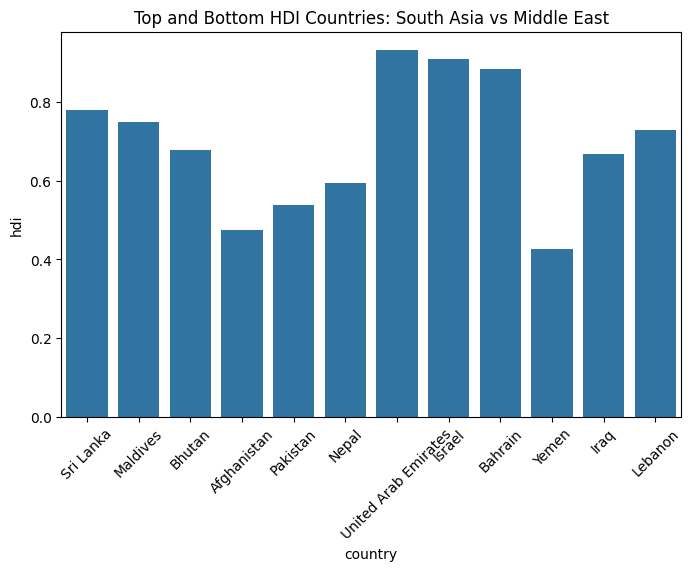

In [83]:
top_sa = sa_3.groupby('country')['hdi'].mean().sort_values(ascending=False).head(3)
bottom_sa = sa_3.groupby('country')['hdi'].mean().sort_values().head(3)

top_me = me_3.groupby('country')['hdi'].mean().sort_values(ascending=False).head(3)
bottom_me = me_3.groupby('country')['hdi'].mean().sort_values().head(3)

compare_df = pd.concat([
    top_sa, bottom_sa, top_me, bottom_me
]).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=compare_df, x='country', y='hdi')
plt.title("Top and Bottom HDI Countries: South Asia vs Middle East")
plt.xticks(rotation=45)
plt.show()


#Task 4: Metric Comparison

In [70]:
metrics = ['gender_development','life_expectancy','gross_inc_percap']


In [84]:
metric_avg = hdi_1b[hdi_1b['region'].isin(['South Asia','Middle East'])] \
    .groupby('region')[metrics].mean().reset_index()

metric_avg


,region,gender_development,life_expectancy,gross_inc_percap
0,Middle East,0.939867,77.727667,52060.945113
1,South Asia,0.881458,70.970083,7766.509931


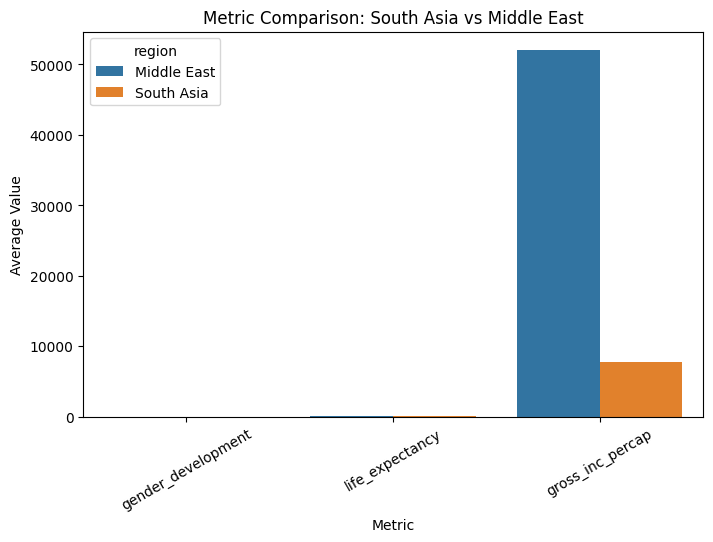

In [85]:
metric_avg_melted = metric_avg.melt(
    id_vars='region',
    value_vars=metrics,
    var_name='Metric',
    value_name='Average Value'
)

plt.figure(figsize=(8,5))
sns.barplot(data=metric_avg_melted, x='Metric', y='Average Value', hue='region')
plt.title("Metric Comparison: South Asia vs Middle East")
plt.xticks(rotation=30)
plt.show()


Life expectancy and income show the largest differences between South Asia and the Middle East.


#Task 5: HDI Variation

In [72]:
(sa_3['hdi'].max() - sa_3['hdi'].min())
(me_3['hdi'].max() - me_3['hdi'].min())


0.5130000000000001

In [73]:
sa_3['hdi'].std() / sa_3['hdi'].mean()
me_3['hdi'].std() / me_3['hdi'].mean()


np.float64(0.17910145193048382)

South Asia shows greater variation in HDI, indicating uneven development across countries.


#Task 6: Correlation Analysis (add)

In [91]:
sa_3[['hdi','life_expectancy','gender_development']].corr()
me_3[['hdi','life_expectancy','gender_development']].corr()


,hdi,life_expectancy,gender_development
hdi,1.000000,0.933123,0.935670
life_expectancy,0.933123,1.000000,0.912836
gender_development,0.935670,0.912836,1.000000


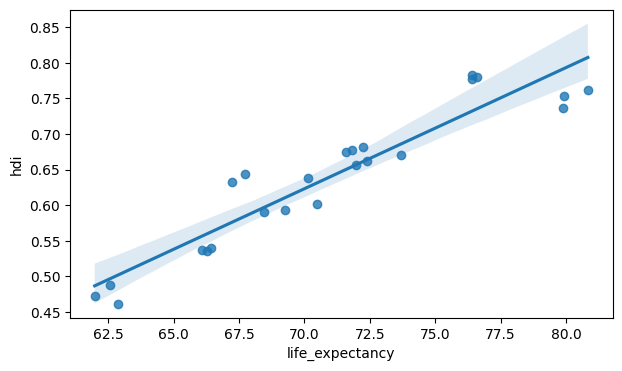

In [92]:
plt.figure(figsize=(7,4))
sns.regplot(data=sa_3, x='life_expectancy', y='hdi')
plt.show()


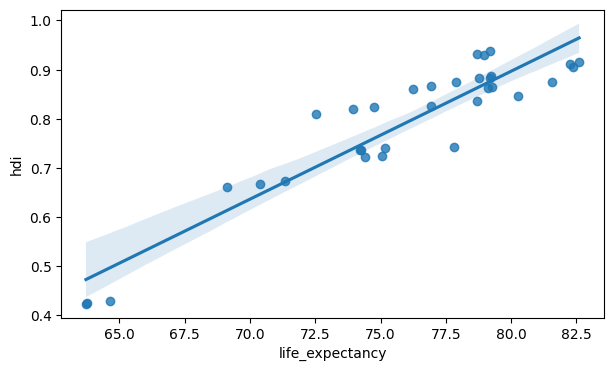

In [93]:
plt.figure(figsize=(7,4))
sns.regplot(data=me_3, x='life_expectancy', y='hdi')
plt.show()


#TASK 7: Outlier Detection

In [95]:
def iqr_flag(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    return (df[col] < (q1 - 1.5*iqr)) | (df[col] > (q3 + 1.5*iqr))


In [97]:
sa_3['outlier'] = iqr_flag(sa_3,'hdi') | iqr_flag(sa_3,'gross_inc_percap')
me_3['outlier'] = iqr_flag(me_3,'hdi') | iqr_flag(me_3,'gross_inc_percap')


/tmp/ipython-input-2627969357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sa_3['outlier'] = iqr_flag(sa_3,'hdi') | iqr_flag(sa_3,'gross_inc_percap')
/tmp/ipython-input-2627969357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  me_3['outlier'] = iqr_flag(me_3,'hdi') | iqr_flag(me_3,'gross_inc_percap')




Outliers were identified using the 1.5×IQR rule for HDI and GNI per capita. Countries outside this range were highlighted in scatter plots to examine exceptional cases. These outliers may represent countries with unusually high income relative to HDI or stronger human development outcomes despite lower income levels.
